## Validação Estatística: Testes de Hipóteses e Técnicas de Amostragem

**Estatística Aplicada**   
**MBA em Data Science & Advanced Analytics**

---

### 📌 Visão Geral do Script
Este notebook reúne a resolução analítica e conceitual focada em **Estatística Inferencial**, demonstrando a aplicação prática de **Testes de Hipóteses** e a validação de **Métodos de Amostragem**. O objetivo principal é consolidar a capacidade de formular premissas estatísticas, tomar decisões baseadas em p-valores e interpretar criticamente os resultados dentro de cenários reais.

### 📊 Conceitos e Aplicações Validadas
1. **Formulações de Hipóteses e Testes Paramétricos ($t$-test):** Modelagem de testes unilaterais para a comparação de médias de atributos antropométricos (altura) entre diferentes grupos comportamentais.
2. **Análise de Variáveis de Confusão:** Discussão crítica sobre a diferença entre relevância estatística e causalidade prática, identificando potenciais vieses ocultos (como gênero e idade) nos resultados brutos da população.
3. **Avaliação de Amostragem Estratificada:** Aplicação de testes de hipóteses bilaterais para validar se uma amostra reduzida e estratificada preserva adequadamente as características médias e a consistência da população original (variável peso).

### 🛠️ Conceitos Chave Demonstrados
* Testes Paramétricos ($t$-Student Unilateral e Bilateral)
* Nível de Significância ($\alpha$), P-valor e Tomada de Decisão
* Erro do Tipo I e Região de Rejeição de $H_0$
* Consistência Amostral e Validação Populacional

---

#### **1. Teste de Hipótese: Diferença de altura entre fumantes e não fumantes.**
   
Teste a hipótese de que a altura média (Altura_cm) de adultos que já fumaram ≥100 cigarros (variável JaFumou100Cigarros) é maior do que a de adultos que nunca fumaram.

Formule:  
-	H0: μ_fumantes ≤ μ_não_fumantes
-	HA: μ_fumantes > μ_não_fumantes

Use t-test unilateral e escolha um nível de significância justificando a sua escolha diante do contexto dos dados.

Entregáveis:
-	Estatística t
-	p-valor unilateral
-	Conclusão interpretada no contexto da Aula 4

In [3]:
# =====================================
# 0. IMPORTAÇÃO DE BIBLIOTECAS
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Para QQ-plot
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# =====================================
# 1. CONFIGURAÇÃO BÁSICA
# =====================================

# Nome do arquivo NHANES (ajuste o caminho se necessário)
NHANES_PATH = "nhanes_2015_2016.csv"

# Nomes de colunas usados (do CSV em português)
COL_ID       = "ID_Participante"
COL_ALCOOL   = "ConsumiuAlcool12Meses"
COL_FUMOU    = "JaFumou100Cigarros"
COL_SEXO     = "Sexo"
COL_IDADE    = "Idade"
COL_IMC      = "IMC"
COL_PESO     = "Peso_kg"
COL_ALTURA   = "Altura_cm"
COL_RACA     = "RacaEtnia"
COL_ESCOLAR  = "Escolaridade"
COL_BP_SYS1  = "PressaoSistolica_1"
COL_BP_DIA1  = "PressaoDiastolica_1"
COL_BP_SYS2  = "PressaoSistolica_2"
COL_BP_DIA2  = "PressaoDiastolica_2"

In [4]:
# =====================================
# 2. CARREGAMENTO E PRÉ-PROCESSAMENTO
# =====================================

df = pd.read_csv(NHANES_PATH)

print("Tamanho original do dataset:", df.shape)
print("\nColunas disponíveis:\n", df.columns)

Tamanho original do dataset: (5735, 28)

Colunas disponíveis:
 Index(['ID_Participante', 'ConsumiuAlcool12Meses', 'FrequenciaConsumoAlcool',
       'QuantidadeBebida', 'JaFumou100Cigarros', 'Sexo', 'Idade', 'RacaEtnia',
       'Cidadania', 'Escolaridade', 'EstadoCivil', 'TamanhoDomicilio',
       'WTINT2YR', 'UnidadePrimariaAmostra', 'SDMVSTRA', 'INDFMPIR',
       'PressaoSistolica_1', 'PressaoDiastolica_1', 'PressaoSistolica_2',
       'PressaoDiastolica_2', 'Peso_kg', 'Altura_cm', 'IMC',
       'ComprimentoPerna', 'ComprimentoBraco', 'CircunferenciaBraco',
       'CircunferenciaCintura', 'PossuiPlanoSaude'],
      dtype='object')


In [5]:
# Vamos considerar apenas adultos (Idade >= 18) para vários testes
df_adultos = df[df[COL_IDADE] >= 18].copy()

# Remover linhas com NaN nas colunas relevantes
cols_importantes = [
                    COL_IDADE, COL_SEXO, COL_IMC, COL_PESO, COL_ALTURA,
                    COL_FUMOU, COL_RACA, COL_ESCOLAR,
                    COL_BP_SYS1, COL_BP_DIA1, COL_BP_SYS2, COL_BP_DIA2
                    ]

cols_existentes = [c for c in cols_importantes if c in df_adultos.columns]
df_adultos = df_adultos.dropna(subset=cols_existentes)

print("Tamanho após filtro de adultos + remoção de NaNs:", df_adultos.shape)

Tamanho após filtro de adultos + remoção de NaNs: (5070, 28)


In [6]:
# Definindo os limites para Altura (cm) Adultos
# Excluir outleirs identificados no QQ Plot df_adultos que pode estar afetando a media e testes 

estatisticas_altura = df_adultos[COL_ALTURA].describe()
print(estatisticas_altura)

L_inf = 140
L_sup = 200

# Filtra o DataFrame, mantendo apenas os valores dentro dos limites
df_adultos_limpo = df_adultos[
    (df_adultos[COL_ALTURA] >= L_inf) &
    (df_adultos[COL_ALTURA] <= L_sup)
].copy()

print(f"Número de observações no dataset original: {df_adultos.shape[0]}")
print(f"Número de observações após a limpeza: {df_adultos_limpo.shape[0]}")

count    5070.000000
mean      166.125207
std        10.109477
min       129.700000
25%       158.700000
50%       165.950000
75%       173.575000
max       202.700000
Name: Altura_cm, dtype: float64
Número de observações no dataset original: 5070
Número de observações após a limpeza: 5058



=== T-Test Independente Unilateral: Altura por Fumantes (já fumaram ≥100 cigarros) ===
Qtde Fumantes: 2133
Qtde Não Fumantes: 2917
Média Altura Fumantes: 168.49 cm
Média Altura Não Fumantes: 164.47 cm
Estatística t: 14.51087744513395
p-valor unilateral: 5.09349642003971e-47
Conclusão HA: Rejeitamos H0 -> Há evidências estatísticas de que a altura média dos fumantes é maior do que a dos não fumantes.


<Figure size 600x500 with 0 Axes>

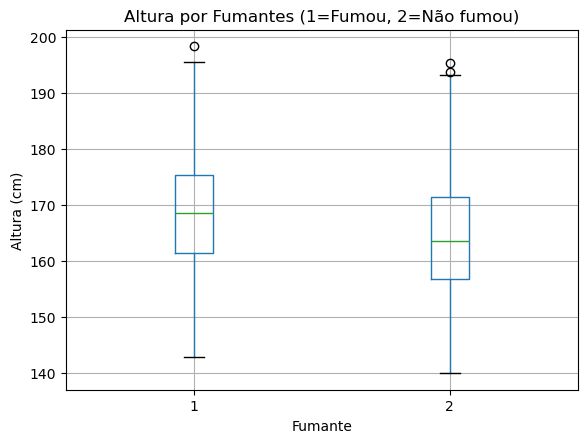

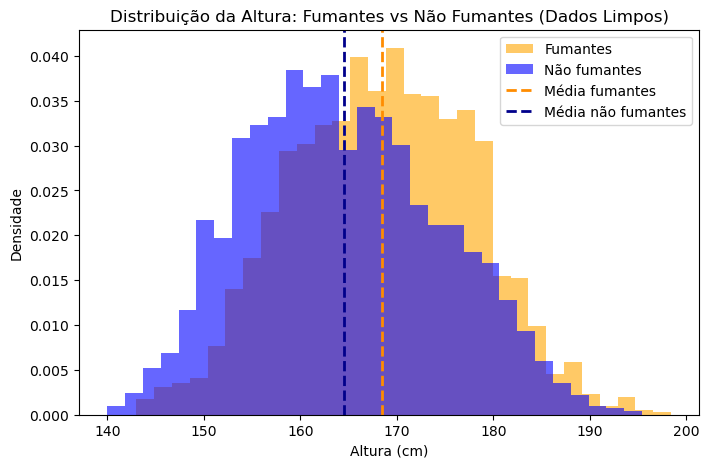

In [ ]:
# T-Test Independente Unilateral (Fumantes)
# H0: μ_fumantes ≤ μ_não_fumantes
# HA: μ_fumantes > μ_não_fumantes

# ================================
# 1. Separar os grupos
# ================================

# valores fumates:
# 1 = já fumou >= 100 cigarros
# 2 = não fumou >= 100 cigarros

fumantes = df_adultos_limpo.loc[df_adultos_limpo[COL_FUMOU] == 1, COL_ALTURA]
nao_fumantes = df_adultos_limpo.loc[df_adultos_limpo[COL_FUMOU] == 2, COL_ALTURA]

print("\n=== T-Test Independente Unilateral: Altura por Fumantes (já fumaram ≥100 cigarros) ===")
print("Qtde Fumantes:", fumantes.shape[0])
print("Qtde Não Fumantes:", nao_fumantes.shape[0])


# ================================
# 2. Calcular médias
# ================================

media_fumantes = fumantes.mean()
media_nao_fumantes = nao_fumantes.mean()

print(f"Média Altura Fumantes: {media_fumantes:.2f} cm")
print(f"Média Altura Não Fumantes: {media_nao_fumantes:.2f} cm")

# ================================
# 3. t-test independente unilateral
# ================================

alpha = 0.05  # nível de significância (5%)

t_stat, p_val_bilateral = stats.ttest_ind(
    fumantes,
    nao_fumantes,
    equal_var=False  # welch (mais seguro)
)

# Ajuste para teste unilateral (direita) Fumantes
p_val_unilateral = p_val_bilateral / 2

print("Estatística t:", t_stat)
print("p-valor unilateral:", p_val_unilateral)


# Codificando o teste de hipoteses - H0 vs HA (H0 valores tendem a normalidade)
if p_val_unilateral < alpha:
    print("Conclusão HA: Rejeitamos H0 -> Há evidências estatísticas de que a altura média dos fumantes é maior do que a dos não fumantes.")
else:
    print("Conclusão H0: Não rejeitamos H0 -> Não há evidências estatísticas suficientes de que a altura média dos fumantes seja maior do que a dos não fumantes.")


# Boxplot IMC por sexo

df_plot = df_adultos_limpo.loc[df_adultos_limpo[COL_FUMOU].isin([1, 2])].copy()
plt.figure(figsize=(6, 5))
df_plot.boxplot(column=COL_ALTURA, by=COL_FUMOU)
plt.title("Altura por Fumantes (1=Fumou, 2=Não fumou)")
plt.suptitle("")
plt.xlabel("Fumante")
plt.ylabel("Altura (cm)")
plt.show()

# Histograma
plt.figure(figsize=(8, 5))

#Fumantes (Orange)
plt.hist(fumantes, bins=30, alpha=0.6, density=True,
         label="Fumantes", color='orange')

# Não Fumantes (Azul)
plt.hist(nao_fumantes, bins=30, alpha=0.6, density=True,
         label="Não fumantes", color='blue')

# Linhas das médias
# Média Fumantes (DarkOrange)
plt.axvline(media_fumantes, linestyle='--', linewidth=2, color='darkorange',
            label="Média fumantes")

# Média Não Fumantes (DarkBlue)
plt.axvline(media_nao_fumantes, linestyle='--', linewidth=2, color='darkblue',
            label="Média não fumantes")

plt.xlabel("Altura (cm)")
plt.ylabel("Densidade")
plt.title("Distribuição da Altura: Fumantes vs Não Fumantes")
plt.legend()
plt.show()


In [33]:
# ================================================
# ANALISE DO FATOR GENERO (SEXO)
# ================================================

# Filtrar o DataFrame Limpo apenas para os grupos 1 (Fumou) e 2 (Não Fumou)
df_analise_sexo = df_adultos_limpo[df_adultos_limpo[COL_FUMOU].isin([1, 2])]

print("\n=== Distribuição de Sexo por Fumantes ===")

# Contagem absoluta
contagem_absoluta = df_analise_sexo.groupby(COL_FUMOU)[COL_SEXO].value_counts().unstack(fill_value=0)
print("\nContagem Absoluta (Linha: Status Fumo | Coluna: Sexo):")
print(contagem_absoluta)

# Contagem em proporção (percentual) dentro de cada grupo de Fumo
contagem_proporcao = df_analise_sexo.groupby(COL_FUMOU)[COL_SEXO].value_counts(normalize=True).mul(100).unstack(fill_value=0)

print("\nProporção por Status de Fumo (Em %):")
# Renomeando as linhas para facilitar a leitura no print
contagem_proporcao.index = ['Fumantes (1)', 'Não Fumantes (2)']
print(contagem_proporcao.round(1))

# Armazenando proporções para uso na conclusão (ex: proporção de Homens em Fumantes)
prop_homens_fumantes = contagem_proporcao.loc['Fumantes (1)', 1]
prop_mulheres_fumantes = contagem_proporcao.loc['Fumantes (1)', 2]



=== Distribuição de Sexo por Fumantes ===

Contagem Absoluta (Linha: Status Fumo | Coluna: Sexo):
Sexo                   1     2
JaFumou100Cigarros            
1                   1300   833
2                   1141  1776

Proporção por Status de Fumo (Em %):
Sexo                 1     2
Fumantes (1)      60.9  39.1
Não Fumantes (2)  39.1  60.9


#### **1. Conclusão: Teste de Hipótese T-Test Unilateral - Diferença de altura entre fumantes e não fumantes** 
**Hipótese:** 
A altura média (cm) de adultos que já fumaram ≥100 cigarros é maior do que a de adultos que não fumaram ≥100 cigarros.
* **H0:** $\mu_{\text{fumantes}} \le \mu_{\text{não\_fumantes}}$
* **HA:** $\mu_{\text{fumantes}} > \mu_{\text{não\_fumantes}}$

**Delineamento do Teste:** Para o teste de hipótese, foi utilizado o método t-Test unilateral com **nível de significância de 5% ($\alpha = 0.05$)**, estabelecendo um nível de confiança de 95%. Como o estudo envolve fatores antropométricos e comportamentais de saúde pública (e não um ensaio clínico de alta criticidade médica ou risco de vida imediato), o limite clássico de 5% para o erro do Tipo I é perfeitamente adequado e seguro para o contexto dos dados.

Para garantir a consistência da análise, foram aplicados os seguintes filtros para as variáveis:
* **Idade:** Adultos (acima de 18 anos).
* **Tabagismo:** Apenas respostas válidas (1 = Sim, 2 = Não).
* **Altura:** Range de 140 cm a 200 cm para exclusão de potenciais *outliers* de preenchimento.

**Métricas Amostrais:** * **Qtde Fumantes ($n_1$):** 2.133 | **Média Altura:** 168,49 cm
* **Qtde Não Fumantes ($n_2$):** 2.917 | **Média Altura:** 164,47 cm

**Resultados Estatísticos:**
* **Estatística t:** 14.51
* **p-valor unilateral:** $5.09 \times 10^{-47}$
* **Decisão:** Rejeita-se a hipótese nula ($H_0$).

---

**Conclusão e Análise Crítica:**

Como o $p$-valor obtido é virtualmente zero e significativamente inferior ao nível de significância adotado ($\alpha = 0.05$), **rejeita-se a hipótese nula ($H_0$) em favor da hipótese alternativa ($H_A$)**. Estatisticamente, há evidências robustas para afirmar que a média de altura dos adultos que já fumaram é maior do que a daqueles que nunca fumaram.

Contudo, sob a ótica de Data Science e no contexto metodológico da disciplina, **relevância estatística não implica causalidade**. Biologicamente, o hábito de fumar não causa ganho de estatura em adultos. 

Este resultado contraintuitivo é reflexo de uma **variável de confusão oculta nos dados brutos: o Gênero**. A análise interna da composição dos grupos revelou que o grupo de fumantes é predominantemente masculino (60,9% homens), enquanto o grupo de não fumantes é majoritariamente feminino (60,9% mulheres). Como homens apresentam, por características biológicas populacionais, médias de altura maiores, o teste t acabou captando o viés de gênero entre os grupos, e não um efeito do tabagismo. Para conclusões causais isoladas, seria estritamente necessária uma abordagem multivariada (como uma regressão linear).

#### **2. Teste de Normalidade (Shapiro-Wilk) para Pressão Diastólica por Grupo de Sexo.**
Verifique se a variável PressaoDiastolica_1 segue distribuição normal separadamente
para homens e para mulheres.

Entregáveis:
- reporte a estatística do teste
- p-valor
- conclua se H0 ("dados são normais") deve ser rejeitada. 
 
Responda:  
Qual dos dois grupos demonstra maior desvio da normalidade? Explique.

Média Homens: 69.69
Média Mulheres: 68.52

Estatísticas do Shapiro-Wilk
Homens: estatística=0.9510, p-valor=0.0000
Mulheres: estatística=0.9942, p-valor=0.0520

Conclusão:
Homens:  HA: não seguem a normalidade (rejeita H0).
Mulheres:  H0: seguem a normalidade.
Maior desvio da normalidade: Homens


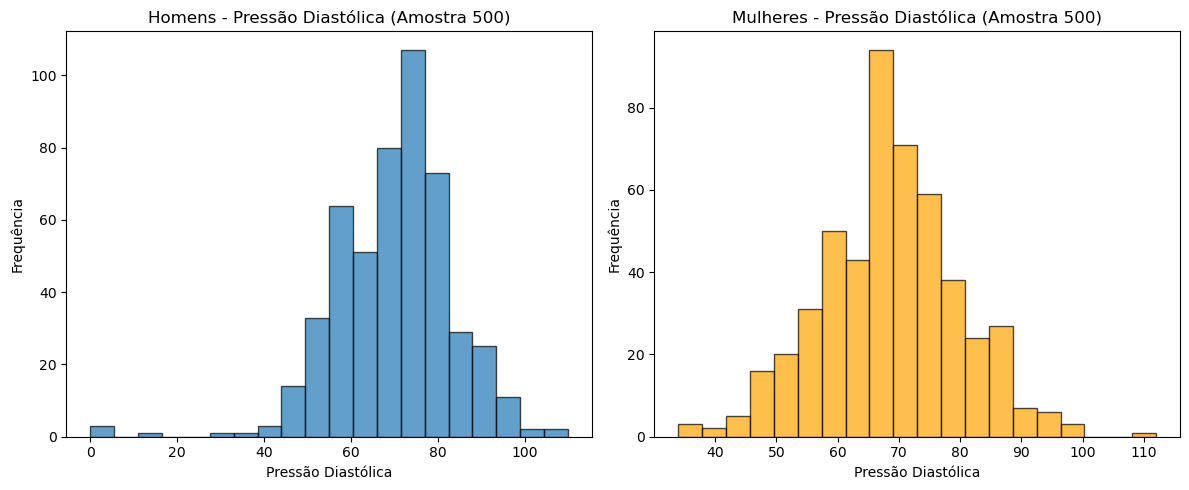

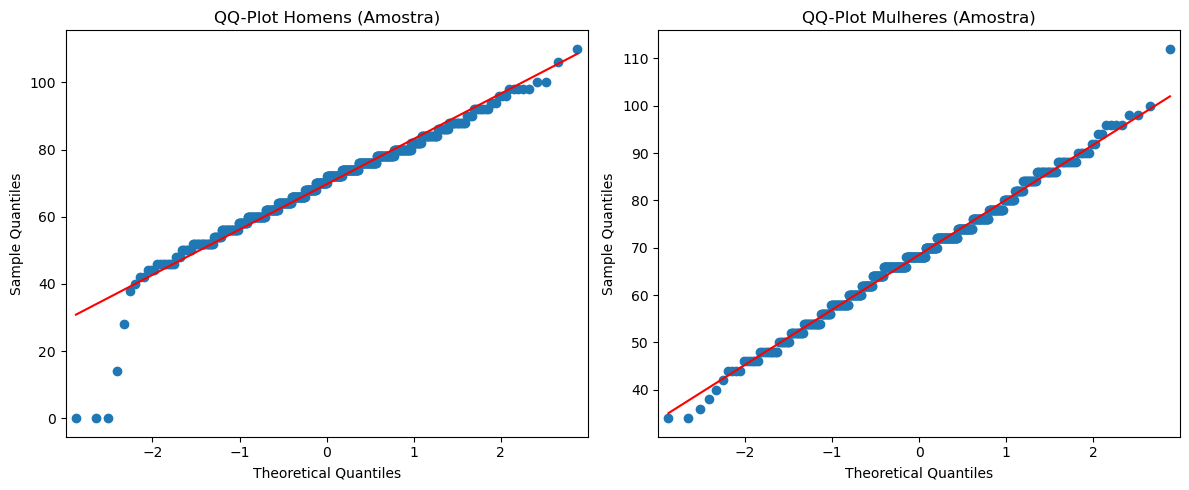

In [ ]:
# Teste de Normalidade - Shapiro Wilk - Pressão Diastólica por Grupo Sexo

# Separar por sexo
homens = df_adultos[df_adultos[COL_SEXO] == 1][COL_BP_DIA1]
mulheres = df_adultos[df_adultos[COL_SEXO] == 2][COL_BP_DIA1]

# --- Amostras aleatórias (até 500) ---
homens_s = homens.sample(n=min(500, len(homens)), random_state=42)
mulheres_s = mulheres.sample(n=min(500, len(mulheres)), random_state=42)

# Médias da pressão diastólica
media_h = homens_s.mean()
media_m = mulheres_s.mean()
print(f"Média Homens: {media_h:.2f}")
print(f"Média Mulheres: {media_m:.2f}")

# nível de significância
alpha = 0.05

# H0: os dados seguem distribuição normal
# HA: os dados não seguem distribuição normal

# --- Teste Shapiro-Wilk ---
stat_h, p_h = stats.shapiro(homens_s)
stat_m, p_m = stats.shapiro(mulheres_s)

print("\nEstatísticas Shapiro-Wilk")
print(f"Homens: estatística={stat_h:.4f}, p-valor={p_h:.4f}")
print(f"Mulheres: estatística={stat_m:.4f}, p-valor={p_m:.4f}")

# Conclusão usando alpha
print("\nConclusão:")
print("Homens: ", "HA: não seguem a normalidade (rejeita H0)." if p_h < alpha else "H0: seguem a normalidade.")
print("Mulheres: ", "HA: não seguem normalidade (rejeita H0)." if p_m < alpha else "H0: seguem a normalidade.")

# Comparação de desvio
if p_h < p_m:
    print("Maior desvio da normalidade: Homens")
elif p_m < p_h:
    print("Maior desvio da normalidade: Mulheres")
else:
    print("Desvio semelhante entre os grupos")

# --- Histogramas ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(homens_s, bins=20, edgecolor='black', alpha=0.7)
plt.title("Homens - Pressão Diastólica (Amostra 500)")
plt.xlabel("Pressão Diastólica")
plt.ylabel("Frequência")

plt.subplot(1,2,2)
plt.hist(mulheres_s, bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.title("Mulheres - Pressão Diastólica (Amostra 500)")
plt.xlabel("Pressão Diastólica")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

# --- QQ-Plots ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sm.qqplot(homens_s, line='s', ax=plt.gca())
plt.title("QQ-Plot Homens (Amostra)")

plt.subplot(1,2,2)
sm.qqplot(mulheres_s, line='s', ax=plt.gca())
plt.title("QQ-Plot Mulheres (Amostra)")

plt.tight_layout()
plt.show()


#### **2. Conclusão: Teste de Normalidade Shapiro-Wilk - Pressão Diastólica por Grupo de Sexo**  
**Teste:** Verifique se a variável PressaoDiastolica_1 segue distribuição normal separadamente para homens e para mulheres.
Entregáveis: reporte a estatística do teste, p-valor, conclua se H0 ("dados são normais") deve ser rejeitada. 
Responda: Qual dos dois grupos demonstra maior desvio da normalidade? Explique. 

Para o teste foi utilizado o método Teste de Normalidade Shapiro-Wilk com amostras de n=500 para cada grupo, com nível de significância 0.05 (5%), logo, nível de confiança de 95%. Tambem foram utilizados os filtros de idade para apenas maior que 18 anos (adultos) e sexo = (1=homens, 2=mulheres).  
Hipoteses: H0: os dados seguem distribuição normal, HA: os dados não seguem distribuição normal.

**Metricas:**
- Média Homens: 69.69
- Média Mulheres: 68.52

**Estatísticas:**
- Homens: estatística=0.9510, p-valor=0.0000
- Mulheres: estatística=0.9942, p-valor=0.0520

**Resultados do teste:**  
- Homens: HA: não seguem a normalidade (rejeita H0).  
- Mulheres: H0: seguem a normalidade.  
- Maior desvio da normalidade: Homens. 

**Análise:**
 
Homens:
- O histograma mostra uma distribuição levemente assimétrica à direita, indicando que há mais valores altos afastados da média.
- O QQ-Plot evidencia dispersão dos pontos, especialmente na cauda esquerda, confirmando o desvio da normalidade.
- A média ligeiramente maior (69.69) também ajuda a contextualizar o centro da distribuição.

Mulheres:
- O histograma apresenta distribuição mais simétrica e centrada, com a maioria dos valores próximos à média (68.52).
- O QQ-Plot mostra que quase todos os pontos seguem a linha reta, apenas um pequeno outlier fora, indicando que a normalidade é aproximadamente mantida.

**Conclusão:** Os gráficos e métricas reforçam os resultados do teste Shapiro-Wilk.  
O teste e os gráficos indicam que a pressão diastólica dos homens não segue distribuição normal, enquanto das mulheres segue aproximadamente a normalidade. O grupo dos homens apresenta maior desvio da normalidade, evidenciado tanto pelos valores extremos quanto pelo QQ-Plot.

#### **3. Associação entre Escolaridade e Consumo de Álcool**
Pergunta: Utilize o teste Qui-Quadrado de Independência para verificar:  
Escolaridade (Escolaridade) é independente do consumo de álcool nos últimos 12 meses (ConsumiuAlcool12Meses)?

O que entregar:
-	tabela de contingência
-	estatística χ², p-valor e graus de liberdade
-	conclusão sobre independência
-	interpretação contextual utilizando o conceito de H0 e HA das páginas 13–15 do slide.


=== Teste Qui-Quadrado de Independência: Escolaridade x Consumo de Álcool ===

Tabela de contingência:
 ConsumiuAlcool12Meses  1.0  2.0  9.0
Escolaridade                        
1.0                    264  274    0
2.0                    375  185    0
3.0                    738  293    1
4.0                    989  398    2
5.0                    833  310    0
9.0                      0    2    0

Qui-Quadrado: 122.119
Graus de liberdade: 10
p-valor: 0.00000
Conclusão: HA: (H0 é rejeitada) -> Há associação entre Escolaridade e Consumo de Álcool, as variáveis não são independentes.


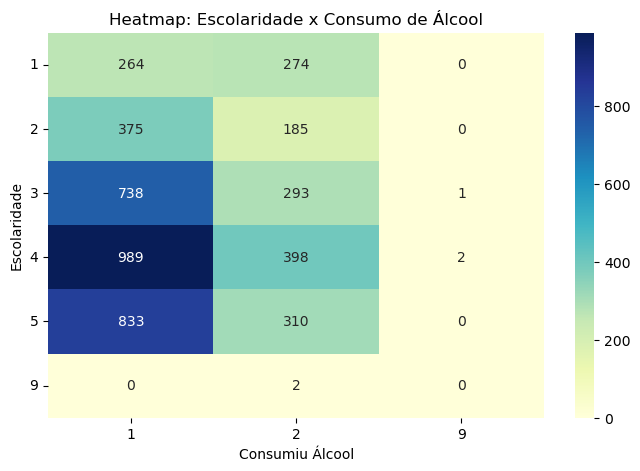

In [16]:
# ===========================================
# TESTE QUI-QUADRADO DE INDEPENDÊNCIA
# Escolaridade x Consumo de Álcool
# ===========================================

"""
H0: Escolaridade e Consumo de Álcool são independentes
HA: Há associação entre Escolaridade e Consumo de Álcool
"""

# --- 1: Preparar dados e tabela de contingência ---
cols_test3 = [COL_ESCOLAR, COL_ALCOOL]
df_test3 = df_adultos.dropna(subset=cols_test3)

# Converter para inteiro usando .loc
df_test3.loc[:, COL_ESCOLAR] = df_test3.loc[:, COL_ESCOLAR].astype(int)
df_test3.loc[:, COL_ALCOOL] = df_test3.loc[:, COL_ALCOOL].astype(int)

# Criar tabela de contingência
contingencia = pd.crosstab(df_test3[COL_ESCOLAR], df_test3[COL_ALCOOL])

# --- 2: Teste Qui-Quadrado ---
chi2_stat, chi2_p, chi2_dof, chi2_exp = stats.chi2_contingency(contingencia)

print("\n=== Teste Qui-Quadrado de Independência: Escolaridade x Consumo de Álcool ===")
print("\nTabela de contingência:\n", contingencia)
print(f"\nQui-Quadrado: {chi2_stat:.3f}")
print(f"Graus de liberdade: {chi2_dof}")
print(f"p-valor: {chi2_p:.5f}")

# Nível de significância
alpha = 0.05

if chi2_p < alpha:
    print("Conclusão: HA: (H0 é rejeitada) -> Há associação entre Escolaridade e Consumo de Álcool, as variáveis não são independentes.")
else:
    print("Conclusão: H0 -> Não há evidência forte de associação entre Escolaridade e Consumo de Álcool, as variáveis são independentes.")

# --- 3: Heatmap ---
plt.figure(figsize=(8,5))
sns.heatmap(contingencia, annot=True, fmt="d", cmap="YlGnBu")

# Ajustar ticks para mostrar como inteiro
plt.xticks(ticks=np.arange(contingencia.shape[1])+0.5, labels=contingencia.columns.astype(int))
plt.yticks(ticks=np.arange(contingencia.shape[0])+0.5, labels=contingencia.index.astype(int), rotation=0)

plt.title("Heatmap: Escolaridade x Consumo de Álcool")
plt.xlabel("Consumiu Álcool")
plt.ylabel("Escolaridade")
plt.show()


#### **3. Conclusão: Teste Qui-Quadrado – Escolaridade x Consumo de Álcool**
**Teste:** Utilize o teste Qui-Quadrado de Independência para verificar:
- Escolaridade (Escolaridade) é independente do consumo de álcool nos últimos 12 meses (ConsumiuAlcool12Meses)?
- O que entregar: tabela de contingência, estatística χ², p-valor e graus de liberdade, conclusão sobre independência
- interpretação contextual utilizando o conceito de H0 e HA das páginas 13–15 do slide.

Para o teste foram consideradas apenas observações de adultos sem valores faltantes para as variáveis: escolaridade e consumo de álcool (em 12 meses). Foi Criada tabela de contingência cruzando as categorias de escolaridade com consumo de álcool e Aplicado o teste Qui-Quadrado de independência com nível de significância de 5% (α = 0,05). 

**Hipóteses:**
- H0: Escolaridade e Consumo de Álcool são independentes.  
- HA: Há associação entre Escolaridade e Consumo de Álcool.  

**Tabela de contingência:**  

<sub>

| Escolaridade | Consumiu | Não Consumiu | Não Informado |
|-------------:|---------:|-------------:|---------:|
| 1           | 264      | 274          | 0        |
| 2           | 375      | 185          | 0        |
| 3           | 738      | 293          | 1        |
| 4           | 989      | 398          | 2        |
| 5           | 833      | 310          | 0        |
| 9           | 0        | 2            | 0        |

</sub>

**Estatísticas do teste:**  
- Qui-Quadrado = 122.119  
- Graus de liberdade = 10  
- p-valor = 0.00000  

**Resultado do Teste:**  
- Conclusão: HA -> Rejeitamos H0: Há associação entre Escolaridade e Consumo de Álcool, indicando que as variáveis não são independentes.

**Interpretação contextual:**  
O teste mostra que o consumo de álcool não é independente do nível de escolaridade. Isso significa que a variável escolaridade está associada ao consumo de álcool. Como o p-valor é menor que 0,05, rejeitamos a hipótese nula (H0) de que as variáveis são independentes e aceitamos a hipótese alternativa (HA), que indica que há uma associação significativa entre escolaridade e consumo de álcool.
O heatmap da tabela de contingência evidencia visualmente essa associação. Ele mostra que o maior consumo de álcool ocorre entre os níveis 3 e 5 de escolaridade, com as cores mais fortes nesses níveis, sendo o nível 4 o mais representativo. Isso reforça que escolaridade e consumo de álcool não são independentes e estão fortemente associados.

#### **4. Teste de Proporções: Proporção de Obesidade entre Fumantes vs Não-Fumantes.**
- Crie uma variável binária: Obeso = 1 se IMC ≥ 30, caso contrário 0.
- Pergunta: Teste se a proporção de obesos é maior entre fumantes do que entre não fumantes.
- Utilize um Z-test para diferença de proporções.  

Entregáveis:
- proporções dos dois grupos
- estatística Z
- p-valor
- conclusão interpretada.


=== Teste Z para Diferença de Proporções (Obeso x Fumo) ===

Métricas:

--- Proporções e Contagens de Obesos (IMC >= 30) ---
  Fumantes (p_F): 0.4115 (879 de 2136)
  Não-Fumantes (p_NF): 0.3992 (1168 de 2926)

--- IMC Médio Geral ---
  IMC Médio (Fumantes): 29.61
  IMC Médio (Não-Fumantes): 29.41

--- Estatísticas do Teste Z ---
Estatística Z: 0.883
p-valor (unilateral): 0.18854

Conclusão: H0 -> Não há evidência estatística forte de que a proporção de obesos seja maior entre os fumantes (p >= 0.05).


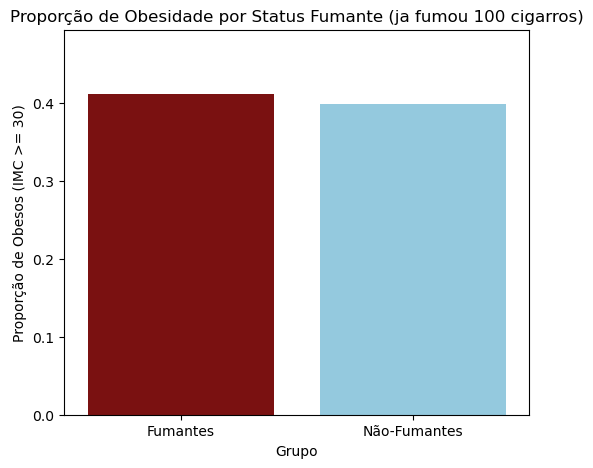

In [7]:
# TESTE Z PARA DIFERENÇA DE PROPORÇÕES (UNILATERAL)
# Obesidade (IMC >= 30) x Fumo (Já Fumou 100+ Cigarros)
# ===========================================

# 'df_adultos' está carregado e filtrado.

# --- Variáveis ---
COL_FUMANTE = 'JaFumou100Cigarros' # 1: Fumante, 2: Não Fumante
COL_IMC = 'IMC'
alpha = 0.05

# 1. Criar a variável binária 'Obeso' e filtrar
df_adultos['Obeso'] = (df_adultos[COL_IMC] >= 30).astype(int)
df_test4 = df_adultos.loc[df_adultos[COL_FUMANTE].isin([1, 2])].copy()

# 2. Separar e Contar
fumantes = df_test4[df_test4[COL_FUMANTE] == 1]
nao_fumantes = df_test4[df_test4[COL_FUMANTE] == 2]

# --- Cálculo das Métricas Quantitativas e Médias ---
count_fumantes = fumantes['Obeso'].sum()
count_nao_fumantes = nao_fumantes['Obeso'].sum()

n_fumantes = len(fumantes)
n_nao_fumantes = len(nao_fumantes)

prop_fumantes = count_fumantes / n_fumantes
prop_nao_fumantes = count_nao_fumantes / n_nao_fumantes

# Cálculo das Médias de IMC
media_imc_fumantes = fumantes[COL_IMC].mean()
media_imc_nao_fumantes = nao_fumantes[COL_IMC].mean()

# 3. Teste Z
count = [count_fumantes, count_nao_fumantes]
nobs = [n_fumantes, n_nao_fumantes]

z_stat, z_p = proportions_ztest(count, nobs=nobs, alternative='larger')

# --- Exibição dos Resultados ---
print("\n=== Teste Z para Diferença de Proporções (Obeso x Fumo) ===")
print("\nMétricas:")
print("\n--- Proporções e Contagens de Obesos (IMC >= 30) ---")
print(f"  Fumantes (p_F): {prop_fumantes:.4f} ({count_fumantes} de {n_fumantes})")
print(f"  Não-Fumantes (p_NF): {prop_nao_fumantes:.4f} ({count_nao_fumantes} de {n_nao_fumantes})")
print("\n--- IMC Médio Geral ---")
print(f"  IMC Médio (Fumantes): {media_imc_fumantes:.2f}")
print(f"  IMC Médio (Não-Fumantes): {media_imc_nao_fumantes:.2f}")
print("\n--- Estatísticas do Teste Z ---")
print(f"Estatística Z: {z_stat:.3f}")
print(f"p-valor (unilateral): {z_p:.5f}")

# Nível de significância
if z_p < alpha:
    print(f"\nConclusão: HA: (H0 é rejeitada) -> A proporção de obesos é estatisticamente maior entre os fumantes (p < {alpha}).")
else:
    print(f"\nConclusão: H0 -> Não há evidência estatística forte de que a proporção de obesos seja maior entre os fumantes (p >= {alpha}).")

# Gráfico de Barras de Proporções

data = pd.DataFrame({'Grupo': ['Fumantes', 'Não-Fumantes'],
                     'Proporção de Obesos': [prop_fumantes, prop_nao_fumantes]})

plt.figure(figsize=(6, 5))
sns.barplot(x='Grupo', y='Proporção de Obesos', hue='Grupo', 
            data=data, palette=['darkred', 'skyblue'], legend=False)
plt.title('Proporção de Obesidade por Status Fumante (ja fumou 100 cigarros)')
plt.ylabel('Proporção de Obesos (IMC >= 30)')
plt.ylim(0, max(prop_fumantes, prop_nao_fumantes) * 1.2) # Ajusta o limite Y
plt.show()

#### **4. Conclusão: Z-Test - Teste de Proporção de Obesidade entre Fumantes vs Não-Fumantes**
**Teste:** Teste se a proporção de obesos é maior entre fumantes do que entre não fumantes.
- Crie uma variável binária: Obeso = 1 se IMC ≥ 30, caso contrário 0.
- Utilize um Z-test para diferença de proporções.  
- Entregáveis: proporções dos dois grupos, estatística Z, p-valor, conclusão interpretada.

Para o teste foi utilizado o método Teste de Proporçoes Z-Test,  com nível de significância 0.05 (5%), logo, nível de confiança de 95%.  
Tambem foram utilizados os filtros de idade para apenas maior que 18 anos (adultos), variável JaFumou100Cigarros (1=sim e 2=nao) e criação da variável binaria: obeso para IMC ≥ 30.  
Hipoteses: H0: A proporção de obesos não é maior entre os fumantes, HA: A proporção de obesos é maior entre os fumantes.

**Métricas**: 
Proporções e Qtde de Obesos (IMC >= 30):
- Fumantes (p_F): 0.4115 (879 de 2136)
- Não-Fumantes (p_NF): 0.3992 (1168 de 2926)
Médias:
- IMC Médio (Fumantes): 29.61
- IMC Médio (Não-Fumantes): 29.41

**Estatísticas:**
- Estatística Z: 0.883
- p-valor (unilateral): 0.18854

**Resultado do Teste:**
- Conclusão: H0 -> Não há evidência estatística forte de que a proporção de obesos seja maior entre os fumantes.

**Conclusão:** 
Apesar de a proporção de obesos ser ligeiramente maior entre os fumantes (41,15%) em comparação aos não-fumantes (39,92%), a diferença é pequena em termos práticos e não foi estatisticamente significativa para o nível de significância de 5%.  
O teste Z para diferença de proporções resultou em uma estatística Z = 0,883 e p-valor unilateral de 0,1885, valor superior ao nível de significância adotado. Assim, não rejeitamos a hipótese nula, indicando que não há evidência estatística suficiente para afirmar que a proporção de obesidade é maior entre os fumantes em relação ao não fumantes.  
Essa conclusão é coerente com o gráfico de barras, no qual se observa que as proporções de obesos nos dois grupos são muito semelhantes, com a barra dos fumantes apenas ligeramente mais alta, sem uma diferença visual expressiva.  
Portanto, com base nos dados analisados, o status de ter fumado 100 ou mais cigarros, não se mostrou associado a uma maior proporção de obesidade nesta amostra, considerando o critério de IMC ≥ 30.

#### **5. Amostragem Estratificada Avançada + Análise Inferencial.**

- Pergunta: Faça uma amostragem estratificada por faixa etária, definindo os estratos:
    - 	18–29
    -	30–44
    -	45–64
    -	65+
- Extraia uma amostra total de 400 indivíduos proporcional aos tamanhos dos estratos.  
- Em seguida responda: A média do Peso_kg dessa amostra estratificada é estatisticamente igual à média da população adulta inteira?
- Realize um t-test simples, formulando:
    - H0: μ_amostra = μ_população
    - HA: μ_amostra ≠ μ_população
    - Interprete o p-valor no contexto da Aula 4 — especialmente sobre significância estatística.



=== t-Test Simples (One Sample) para Peso_kg ===
Média População: 81.65
Média Amostra Estratificada: 81.84
t estatístico: 0.163
p-valor (bicaudal): 0.87053
Nível de significância (alfa): 0.05
Conclusão H0: não rejeitamos H0 -> não há evidência estatística suficiente de que a média do peso da amostra seja diferente da média da população.


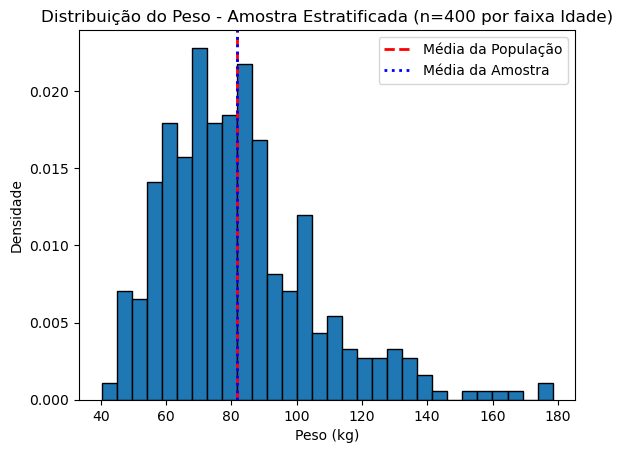

In [13]:
#  Amostragem Estratificada + t-Test Simples (One Sample) - Media Peso (kg)
# ===========================================

"""
Pergunta:
A média do Peso_kg da amostra estratificada (n = 400),
obtida por faixas etárias, é igual à média do Peso_kg
da população adulta?

H0: μ_amostra = μ_população
HA: μ_amostra ≠ μ_população
"""

alpha = 0.05  # nível de significância (5%)

# -------------------------------------------
# 1. Criar estratos por faixa etária
# -------------------------------------------
bins = [18, 29, 44, 64, 120] # limetes das faixas
labels = ['18-29', '30-44', '45-64', '65+']

df_adultos['Faixa_Etaria'] = pd.cut(
    df_adultos[COL_IDADE],
    bins=bins,
    labels=labels
)

# -------------------------------------------
# 2. Amostragem estratificada proporcional
# -------------------------------------------
n_total = 400

amostra_estratificada = (
    df_adultos
    .groupby('Faixa_Etaria', observed=False, group_keys=False)
    .apply(
        lambda x: x.sample(
            n=int(round(len(x) / len(df_adultos) * n_total)),
            random_state=42
        ),
        include_groups=False
    )
)

# -------------------------------------------
# 3. t-test Simples (One Sample)
# -------------------------------------------
peso_amostra = amostra_estratificada[COL_PESO]
media_pop = df_adultos[COL_PESO].mean()

t_stat, p_value = stats.ttest_1samp(
    peso_amostra,
    popmean=media_pop
)

print("\n=== t-Test Simples (One Sample) para Peso_kg ===")
print(f"Média População: {media_pop:.2f}")
print(f"Média Amostra Estratificada: {peso_amostra.mean():.2f}")
print(f"t estatístico: {t_stat:.3f}")
print(f"p-valor (bicaudal): {p_value:.5f}")
print(f"Nível de significância (alfa): {alpha}")

if p_value < alpha:
    print("Conclusão HA: rejeitamos H0 -> a média do peso da amostra é diferente da média da população.")
else:
    print("Conclusão H0: não rejeitamos H0 -> não há evidência estatística suficiente de que a média do peso da amostra seja diferente da média da população.")

# Histograma 
plt.figure()
plt.hist(peso_amostra, bins=30, edgecolor="black", density=True)
# Média da população (referência do teste)
plt.axvline(media_pop, color="red", linestyle="--", linewidth=2,
            label="Média da População")
# Média da amostra
plt.axvline(peso_amostra.mean(), color="blue", linestyle=":",
            linewidth=2, label="Média da Amostra")
plt.title("Distribuição do Peso - Amostra Estratificada (n=400 por faixa Idade)")
plt.xlabel("Peso (kg)")
plt.ylabel("Densidade")
plt.legend()
plt.show()


#### **5. Conclusão: T-Test Simples – Peso Médio (Amostra Estratificada vs População Adulta)**

**Teste**: A média do Peso_kg dessa amostra estratificada é estatisticamente igual à média da população adulta inteira?
- Faça uma amostragem estratificada por faixa etária, definindo os estratos: (18–29, 30–44, 45–64, 65+)
- Extraia uma amostra total de 400 indivíduos proporcional aos tamanhos dos estratos.  
- Realize um t-test simples, formulando: H0: μ_amostra = μ_população, HA: μ_amostra ≠ μ_população
- Interprete o p-valor no contexto da Aula 4 — especialmente sobre significância estatística.

Para o teste foram considerados apenas indivíduos adultos (idade ≥ 18 anos), após a limpeza do conjunto de dados e a remoção de valores ausentes. Foi realizada uma amostragem estratificada para as faixas etárias indicadas, com extração proporcional ao tamanho de cada estrato, totalizando 400 indivíduos. 
Em seguida, aplicou-se o t-test simples (one sample) para comparar a média do peso da amostra estratificada com a média do peso da população adulta.
O teste foi conduzido ao nível de significância de 0,05 (5%), correspondente a um nível de confiança de 95%.

**Hipóteses formuladas:**
- H0: a média do peso da amostra estratificada é igual à média do peso da população adulta.
- HA: a média do peso da amostra estratificada é diferente da média do peso da população adulta.

**Métricas:**
- Média do peso da população adulta: 81,65 kg
- Média do peso da amostra estratificada: 81,84 kg

**Estatísticas**:
- Estatística t: 0,163
- p-valor (bicaudal): 0,87053

**Resultado do Teste:**
- Conclusão: H0 → Não há evidência estatística suficiente para rejeitar a hipótese nula.

**Conclusão:**  
A média do peso da amostra estratificada mostrou-se estatisticamente muito próxima da média do peso da população adulta, uma vez que o p-valor obtido (0,8705) é substancialmente superior ao nível de significância adotado de 5%. Dessa forma, o resultado do teste não rejeita a hipótese nula, indicando que a média da amostra é consistente com o valor de referência (média de peso da população adulta) e que os valores observados são compatíveis com o comportamento esperado da variável peso.  
A diferença observada entre as médias é mínima e não apresenta relevância estatística.
Essa conclusão é consistente com o gráfico apresentado, no qual as linhas correspondentes às médias da amostra e da população praticamente se sobrepõem, indicando que a amostragem estratificada preservou adequadamente a característica média do peso da população adulta.